In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import GridSearchCV, cross_val_score
#from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
#前処理したデータ
data = pd.read_csv("preprocess.csv")

(array([1400., 1268.,    0., 1364.,    0., 1508., 1137.,    0., 1542.,
        1581.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

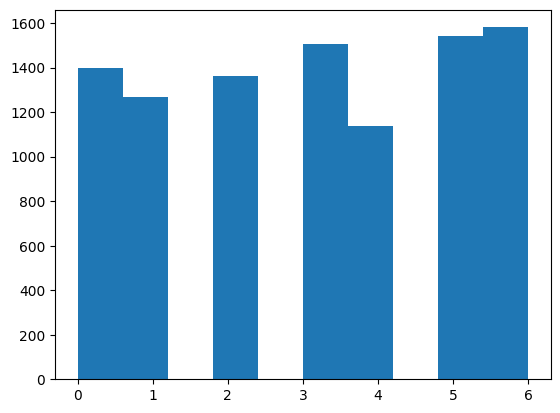

In [3]:
plt.hist(data["price_am"])

In [4]:
#Xとyに分割
X = data.drop(columns=["y"])
y = data["y"]

In [5]:
#最適化及びモデル作成
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

model = RandomForestRegressor()

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
grid_search = grid_search.fit(X, y)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_model = grid_search.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [6]:
#評価
cv_scores = cross_val_score(grid_search.best_estimator_, X, y, cv=5, scoring="neg_mean_absolute_error")

In [7]:
#評価の表示
print("Cross Validation Scores:", cv_scores)

Cross Validation Scores: [-2.21721939 -1.12254082 -1.18942857 -1.68331633 -0.00996429]


In [8]:
#評価平均値の表示
print("Mean Score:", cv_scores.mean())

Mean Score: -1.2444938775510206


In [9]:
#モデルの保存
with open("Apple_model.pickle", mode="wb") as fp:
    pickle.dump(best_model, fp)